In [2]:
! pip install transformer_lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 138.3 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=856babbaf6efb310176781d5dddc69bf170b22d55bd43bb710dc754f8095157a
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: beartype
    Found existing install

In [16]:
import os
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from collections import defaultdict

In [30]:
class HeadAblation:
    """Performs targeted head ablation experiments to measure causal effects on uncertainty tokens."""

    def __init__(self, model_name, prompt_reals, prompt_fakes, results_dir="./results_targeted_ablation"):
        """Initialize the ablation experiment.

        Args:
            model_name (str): Model identifier (e.g., 'gpt2-small', 'opt-125m')
            prompt_reals (list): List of factual prompts
            prompt_fakes (list): List of fictional/unanswerable prompts
            results_dir (str): Base directory for saving results
        """
        self.model_name = model_name
        self.prompt_reals = prompt_reals if isinstance(prompt_reals, list) else [prompt_reals]
        self.prompt_fakes = prompt_fakes if isinstance(prompt_fakes, list) else [prompt_fakes]
        assert len(self.prompt_reals) == len(self.prompt_fakes), "Must have equal number of real and fake prompts"
        self.n_pairs = len(self.prompt_reals)
        self.results_dir = results_dir

        # Setup device and dtype
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        os.makedirs(self.results_dir, exist_ok=True)
        self.model_dir = os.path.join(self.results_dir, model_name.replace("/", "_"))
        os.makedirs(self.model_dir, exist_ok=True)

        # Load model
        print(f"Loading {model_name}...")
        self.model = HookedTransformer.from_pretrained(
            model_name, device=self.device, dtype=self.dtype
        )

        # Get uncertainty tokens
        self.uncertainty_tokens = self._get_uncertainty_tokens()
        print(f"  Uncertainty tokens: {len(self.uncertainty_tokens)} found")

    def _get_uncertainty_tokens(self):
        """Get uncertainty tokens for the model's tokenizer."""
        uncertainty_words = [
            "unknown", "unsure", "don", "'t", "know", "can't", "unable", "impossible",
            "doesn't", "exist", "fictional", "imaginary", "no", "such", "thing",
            "hypothetical", "made", "up", "never", "happened"
        ]
        token_ids = []
        for w in uncertainty_words:
            try:
                toks = self.model.to_tokens(" " + w, prepend_bos=False)[0]
                token_ids.extend(toks.tolist())
            except Exception:
                pass
        return sorted(list(set(token_ids)))

    def _ablate_heads(self, heads_to_ablate, prompt):
        """Ablate specific heads and return logits."""
        heads_by_layer = defaultdict(list)
        for (layer, head) in heads_to_ablate:
            heads_by_layer[layer].append(head)

        hooks = []
        for layer, heads in heads_by_layer.items():
            def make_hook(heads_to_zero):
                def hook_fn(value, hook):
                    value = value.clone()
                    for h in heads_to_zero:
                        value[:, :, h, :] = 0
                    return value
                return hook_fn

            hooks.append((f"blocks.{layer}.attn.hook_z", make_hook(heads)))

        logits = self.model.run_with_hooks(prompt, fwd_hooks=hooks)
        return logits[0, -1]

    def _uncertainty_mass(self, logits):
        """Compute probability mass on uncertainty tokens."""
        probs = torch.softmax(logits, dim=-1)
        return probs[self.uncertainty_tokens].sum().item()

    def _test_single_head(self, layer, head, prompt):
        """Test ablating a single head on a given prompt."""
        # Baseline (no ablation)
        logits_baseline = self.model(self.model.to_tokens(prompt))[0, -1]
        mass_baseline = self._uncertainty_mass(logits_baseline)

        # Ablate the head
        logits_ablated = self._ablate_heads([(layer, head)], prompt)
        mass_ablated = self._uncertainty_mass(logits_ablated)

        # Calculate change
        change = mass_ablated - mass_baseline
        percent_change = (change / mass_baseline * 100) if mass_baseline != 0 else 0

        return {
            "baseline": mass_baseline,
            "ablated": mass_ablated,
            "change": change,
            "percent_change": percent_change
        }


    def _plot_results(self, results_by_pair, target_heads):
        """Generate comprehensive visualization."""
        sorted_heads = sorted(target_heads, key=lambda x: (x[0], x[1]))
        short_labels = [f"L{l}H{h}" for l, h in sorted_heads]

        # Compute averages across pairs
        avg_delta_delta = []
        for head in sorted_heads:
            dds = [results_by_pair[p][head]['delta_delta'] for p in range(self.n_pairs)]
            avg_delta_delta.append(sum(dds) / len(dds))

        # Collect per-pair data
        real_changes_all = [[results_by_pair[p][h]['real']['change'] for h in sorted_heads] for p in range(self.n_pairs)]
        fake_changes_all = [[results_by_pair[p][h]['fake']['change'] for h in sorted_heads] for p in range(self.n_pairs)]
        real_baselines_all = [[results_by_pair[p][h]['real']['baseline'] for h in sorted_heads] for p in range(self.n_pairs)]
        fake_baselines_all = [[results_by_pair[p][h]['fake']['baseline'] for h in sorted_heads] for p in range(self.n_pairs)]

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f"Causal Uncertainty Circuit Analysis - {self.model_name} ({self.n_pairs} pairs)",
                     fontsize=16, fontweight='bold')

        # Plot 1: Average ΔΔ across all pairs
        ax = axes[0, 0]
        colors = ['green' if dd < 0 else 'red' for dd in avg_delta_delta]
        ax.bar(short_labels, avg_delta_delta, color=colors, alpha=0.7,
               edgecolor='black', linewidth=1.5)
        ax.set_ylabel('Average ΔΔ', fontweight='bold')
        ax.set_title(f'Average Differential Effect (n={self.n_pairs} pairs)', fontweight='bold')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(range(len(short_labels)))
        ax.set_xticklabels(short_labels, rotation=45, ha='right')

        # Plot 2: ΔΔ per pair
        ax = axes[0, 1]
        x = range(len(sorted_heads))
        width = 0.8 / self.n_pairs
        for p in range(self.n_pairs):
            dds = [results_by_pair[p][h]['delta_delta'] for h in sorted_heads]
            offset = (p - self.n_pairs/2 + 0.5) * width
            ax.bar([i + offset for i in x], dds, width, label=f'Pair {p+1}', alpha=0.7)
        ax.set_ylabel('ΔΔ (Fake - Real)', fontweight='bold')
        ax.set_title('Per-Pair Differential Effects', fontweight='bold')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=45, ha='right')
        ax.legend(fontsize=8)

        # FIXED: Updated annotation with correct interpretation
        ax.text(0.02, 0.98,
                'ΔΔ = (fake change − real change)\n'
                'Negative ΔΔ = stronger uncertainty drop on fake prompts (causal circuit)\n'
                'Positive ΔΔ = stronger uncertainty drop on real prompts\n\n'
                'Change < 0 ⇒ ablation increases uncertainty (head suppresses it)\n'
                'Change > 0 ⇒ ablation decreases uncertainty (head generates it)',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        # Plot 3: Baseline Comparison (Pair 1)
        ax = axes[1, 0]
        x = range(len(sorted_heads))
        width = 0.35
        ax.bar([i - width/2 for i in x], real_baselines_all[0], width, label='Real Baseline',
               alpha=0.8, color='lightblue')
        ax.bar([i + width/2 for i in x], fake_baselines_all[0], width, label='Fake Baseline',
               alpha=0.8, color='lightcoral')
        ax.set_ylabel('Uncertainty Mass', fontweight='bold')
        ax.set_title('Baseline Uncertainty (Pair 1)', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=45, ha='right')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        # Plot 4: Summary Table
        ax = axes[1, 1]
        ax.axis('off')
        table_data = [['Head', 'Pair', 'Real Δ', 'Fake Δ', 'ΔΔ']]

        for i, (layer, head) in enumerate(sorted_heads):
            for p in range(self.n_pairs):
                r_real = results_by_pair[p][(layer, head)]['real']
                r_fake = results_by_pair[p][(layer, head)]['fake']
                dd = results_by_pair[p][(layer, head)]['delta_delta']

                head_label = f'L{layer}H{head}' if p == 0 else ''
                table_data.append([
                    head_label, f'P{p+1}',
                    f"{r_real['change']:+.2e}",
                    f"{r_fake['change']:+.2e}",
                    f"{dd:+.2e}"
                ])
            # Add average row
            table_data.append([
                '', 'Avg',
                '', '',
                f"{avg_delta_delta[i]:+.2e}"
            ])

        table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.15, 0.10, 0.20, 0.20, 0.20])
        table.auto_set_font_size(False)
        table.set_fontsize(7)
        table.scale(1, 1.5)

        # Style header
        for i in range(5):
            table[(0, i)].set_facecolor('#40466e')
            table[(0, i)].set_text_props(weight='bold', color='white')

        # Style rows
        for i in range(1, len(table_data)):
            head_idx = (i - 1) // (self.n_pairs + 1)
            color = '#f0f0f0' if head_idx % 2 == 0 else 'white'

            # Highlight average rows
            if table_data[i][1] == 'Avg':
                color = '#e0e0e0'

            for j in range(5):
                table[(i, j)].set_facecolor(color)
                # Color ΔΔ column
                if j == 4 and table_data[i][4]:
                    val = float(table_data[i][4])
                    table[(i, j)].set_facecolor('#90EE90' if val < 0 else '#FFB6C6')

        plt.tight_layout()
        plt.show()
        out_path = os.path.join(self.model_dir, "single_head_effects.png")
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {out_path}")

    def _print_summary(self, results_by_pair, target_heads):
        """Print summary table to console."""
        print(f"\n{'='*100}")
        print(f"SUMMARY - {self.model_name} ({self.n_pairs} prompt pairs)")
        print(f"{'='*100}")
        print(f"{'Head':<10} {'Pair':<6} {'Real Δ':<12} {'Fake Δ':<12} {'ΔΔ':<12}")
        print(f"{'-'*100}")

        sorted_heads = sorted(target_heads, key=lambda x: (x[0], x[1]))
        for layer, head in sorted_heads:
            for p in range(self.n_pairs):
                r_real = results_by_pair[p][(layer, head)]['real']
                r_fake = results_by_pair[p][(layer, head)]['fake']
                dd = results_by_pair[p][(layer, head)]['delta_delta']

                head_label = f"L{layer}H{head}" if p == 0 else ""
                marker = "✓" if dd < 0 else "✗"
                print(f"{head_label:<10} P{p+1:<5} {r_real['change']:+12.2e} {r_fake['change']:+12.2e} "
                      f"{dd:+12.2e} {marker}")

            # Print average
            avg_dd = sum(results_by_pair[p][(layer, head)]['delta_delta'] for p in range(self.n_pairs)) / self.n_pairs
            marker = "✓" if avg_dd < 0 else "✗"
            print(f"{'':10} {'Avg':<6} {'':12} {'':12} {avg_dd:+12.2e} {marker}")
            print()

        print(f"{'='*100}")
        print("Note: Negative ΔΔ indicates stronger uncertainty reduction on fake prompts")
        print("(evidence of causal uncertainty circuit)")
        print(f"{'='*100}\n")

    def run(self, target_heads):
        """Run the ablation experiment on specified heads.

        Args:
            target_heads (list): List of (layer, head) tuples to test

        Returns:
            dict: Results for all prompt pairs
        """
        print(f"\n{'='*60}")
        print(f"Experiment: {self.model_name}")
        print(f"Testing {len(target_heads)} heads across {self.n_pairs} prompt pairs")
        print(f"{'='*60}")

        # Store results per pair: results_by_pair[pair_idx][(layer,head)] = {real: ..., fake: ..., delta_delta: ...}
        results_by_pair = [{} for _ in range(self.n_pairs)]

        for layer, head in target_heads:
            print(f"\n  L{layer}H{head}:")

            for pair_idx in range(self.n_pairs):
                print(f"    Pair {pair_idx+1}/{self.n_pairs}:")

                # Test on real prompt
                result_real = self._test_single_head(layer, head, self.prompt_reals[pair_idx])
                print(f"      Real: Δ={result_real['change']:+.2e}")

                # Test on fake prompt
                result_fake = self._test_single_head(layer, head, self.prompt_fakes[pair_idx])
                print(f"      Fake: Δ={result_fake['change']:+.2e}")

                # Compute ΔΔ
                delta_delta = result_fake['change'] - result_real['change']
                marker = "✓" if delta_delta < 0 else "✗"
                print(f"      ΔΔ: {delta_delta:+.2e} {marker}")

                results_by_pair[pair_idx][(layer, head)] = {
                    'real': result_real,
                    'fake': result_fake,
                    'delta_delta': delta_delta
                }

            # Compute average ΔΔ across pairs
            avg_delta_delta = sum(results_by_pair[p][(layer, head)]['delta_delta'] for p in range(self.n_pairs)) / self.n_pairs
            marker = "✓" if avg_delta_delta < 0 else "✗"
            print(f"    Avg ΔΔ: {avg_delta_delta:+.2e} {marker}")

        # Generate plots and summaries
        print(f"\nGenerating visualizations...")
        self._plot_results(results_by_pair, target_heads)
        self._print_summary(results_by_pair, target_heads)

        # Cleanup
        del self.model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

        return results_by_pair


Loading meta-llama/Llama-3.2-1B-Instruct...


Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: meta-llama/Llama-3.2-1B-Instruct
Testing 2 heads across 5 prompt pairs

  L11H0:
    Pair 1/5:
      Real: Δ=-4.77e-07
      Fake: Δ=-1.25e-06
      ΔΔ: -7.75e-07 ✓
    Pair 2/5:
      Real: Δ=-1.91e-06
      Fake: Δ=-1.62e-05
      ΔΔ: -1.43e-05 ✓
    Pair 3/5:
      Real: Δ=-4.77e-07
      Fake: Δ=-3.81e-06
      ΔΔ: -3.34e-06 ✓
    Pair 4/5:
      Real: Δ=-2.98e-07
      Fake: Δ=+1.62e-05
      ΔΔ: +1.65e-05 ✗
    Pair 5/5:
      Real: Δ=-4.35e-06
      Fake: Δ=-7.45e-06
      ΔΔ: -3.10e-06 ✓
    Avg ΔΔ: -1.00e-06 ✓

  L14H0:
    Pair 1/5:
      Real: Δ=+3.58e-07
      Fake: Δ=-1.79e-07
      ΔΔ: -5.36e-07 ✓
    Pair 2/5:
      Real: Δ=+1.43e-06
      Fake: Δ=+8.34e-06
      ΔΔ: +6.91e-06 ✗
    Pair 3/5:
      Real: Δ=+2.38e-07
      Fake: Δ=-4.77e-06
      ΔΔ: -5.01e-06 ✓
    Pair 4/5:
      Real: Δ=+0.00e+00
      Fake: Δ=-1.43e-06
      ΔΔ: -1.43e-06 ✓
    P

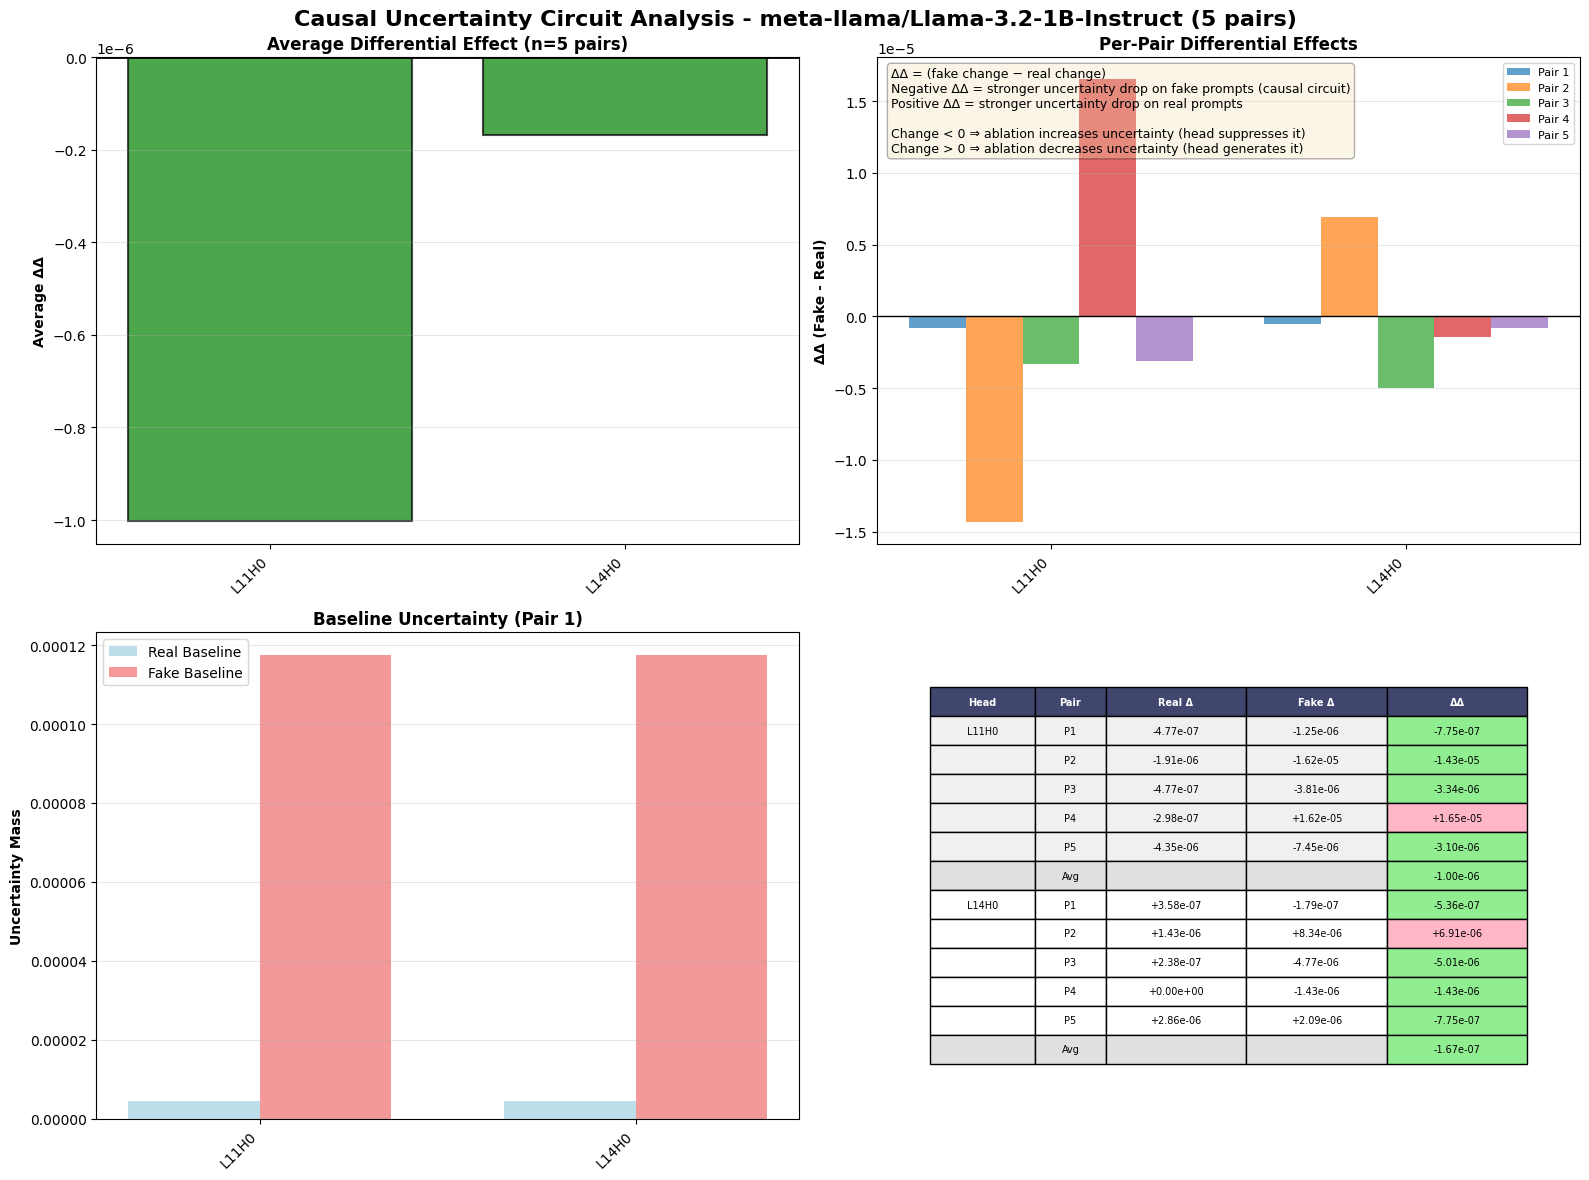

  Saved: ./results_targeted_ablation/meta-llama_Llama-3.2-1B-Instruct/single_head_effects.png

SUMMARY - meta-llama/Llama-3.2-1B-Instruct (5 prompt pairs)
Head       Pair   Real Δ       Fake Δ       ΔΔ          
----------------------------------------------------------------------------------------------------
L11H0      P1        -4.77e-07    -1.25e-06    -7.75e-07 ✓
           P2        -1.91e-06    -1.62e-05    -1.43e-05 ✓
           P3        -4.77e-07    -3.81e-06    -3.34e-06 ✓
           P4        -2.98e-07    +1.62e-05    +1.65e-05 ✗
           P5        -4.35e-06    -7.45e-06    -3.10e-06 ✓
           Avg                                 -1.00e-06 ✓

L14H0      P1        +3.58e-07    -1.79e-07    -5.36e-07 ✓
           P2        +1.43e-06    +8.34e-06    +6.91e-06 ✗
           P3        +2.38e-07    -4.77e-06    -5.01e-06 ✓
           P4        +0.00e+00    -1.43e-06    -1.43e-06 ✓
           P5        +2.86e-06    +2.09e-06    -7.75e-07 ✓
           Avg                       

In [32]:
MODEL_CONFIG = {
    # heuristics from logit lens, peak delta
    "meta-llama/Llama-3.2-1B-Instruct": [
        (11, 0),
        (14, 0),
    ]
}

prompt_reals = [
    "Who was the first US president?",
    "What is the speed of light?",
    "What is 2+2?",
    "What is the capital of France?",
    "If I have 5 apples and eat 2, how many remain?"
]

prompt_fakes = [
    "Who was the first president of the fictional nation of Atlantis?",
    "What is the speed of sound in vacuum?",
    "What is the largest prime number?",
    "What is the capital of Middle Earth?",
    "If I have 5 unicorns and they fly away, how many remain?"
]

# Run experiments
for model_name, target_heads in MODEL_CONFIG.items():
    try:
        exp = HeadAblation(model_name, prompt_reals, prompt_fakes)
        exp.run(target_heads)
    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()

print("All experiments completed!")

Loading meta-llama/Llama-3.2-1B-Instruct...


Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: meta-llama/Llama-3.2-1B-Instruct
Testing 4 heads across 5 prompt pairs

  L11H0:
    Pair 1/5:
      Real: Δ=-4.77e-07
      Fake: Δ=-1.25e-06
      ΔΔ: -7.75e-07 ✓
    Pair 2/5:
      Real: Δ=-1.91e-06
      Fake: Δ=-1.62e-05
      ΔΔ: -1.43e-05 ✓
    Pair 3/5:
      Real: Δ=-4.77e-07
      Fake: Δ=-3.81e-06
      ΔΔ: -3.34e-06 ✓
    Pair 4/5:
      Real: Δ=-2.98e-07
      Fake: Δ=+1.62e-05
      ΔΔ: +1.65e-05 ✗
    Pair 5/5:
      Real: Δ=-4.35e-06
      Fake: Δ=-7.45e-06
      ΔΔ: -3.10e-06 ✓
    Avg ΔΔ: -1.00e-06 ✓

  L11H7:
    Pair 1/5:
      Real: Δ=-2.38e-07
      Fake: Δ=+4.77e-07
      ΔΔ: +7.15e-07 ✗
    Pair 2/5:
      Real: Δ=+5.72e-06
      Fake: Δ=+2.38e-07
      ΔΔ: -5.48e-06 ✓
    Pair 3/5:
      Real: Δ=+2.44e-06
      Fake: Δ=+5.48e-06
      ΔΔ: +3.04e-06 ✗
    Pair 4/5:
      Real: Δ=-5.96e-08
      Fake: Δ=-5.72e-06
      ΔΔ: -5.66e-06 ✓
    P

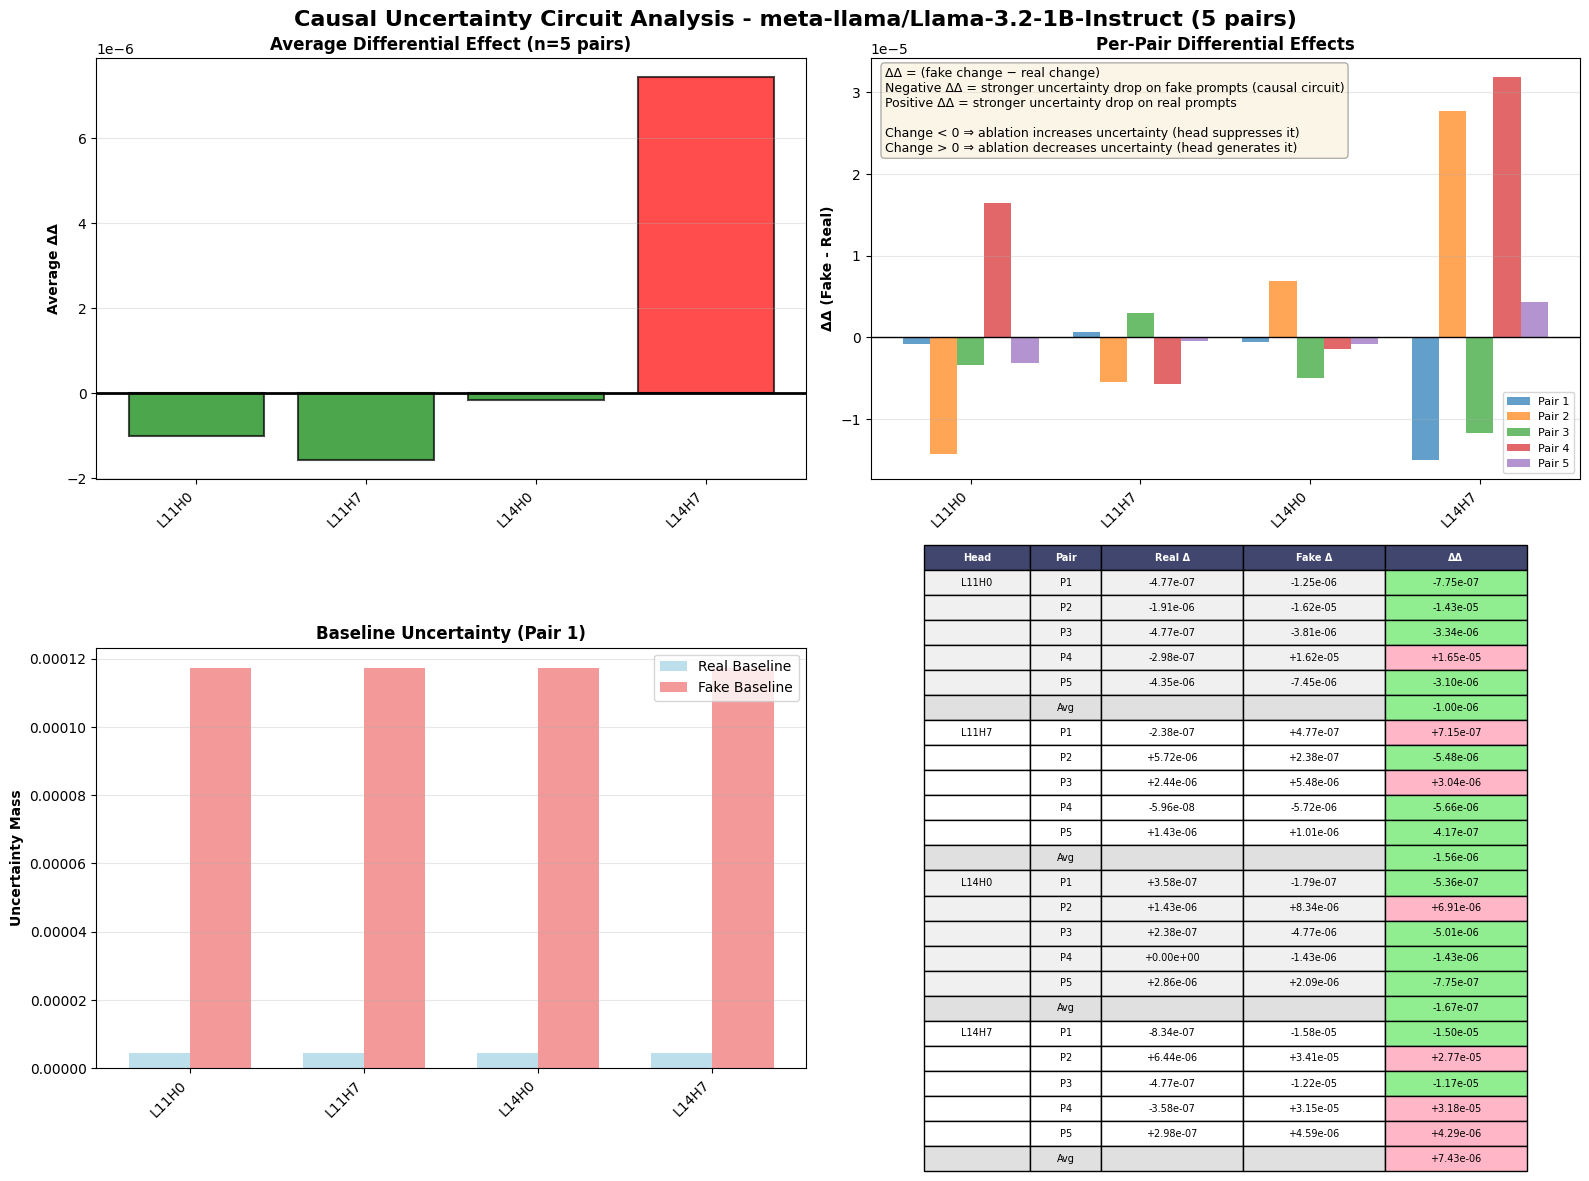

  Saved: ./results_targeted_ablation/meta-llama_Llama-3.2-1B-Instruct/single_head_effects.png

SUMMARY - meta-llama/Llama-3.2-1B-Instruct (5 prompt pairs)
Head       Pair   Real Δ       Fake Δ       ΔΔ          
----------------------------------------------------------------------------------------------------
L11H0      P1        -4.77e-07    -1.25e-06    -7.75e-07 ✓
           P2        -1.91e-06    -1.62e-05    -1.43e-05 ✓
           P3        -4.77e-07    -3.81e-06    -3.34e-06 ✓
           P4        -2.98e-07    +1.62e-05    +1.65e-05 ✗
           P5        -4.35e-06    -7.45e-06    -3.10e-06 ✓
           Avg                                 -1.00e-06 ✓

L11H7      P1        -2.38e-07    +4.77e-07    +7.15e-07 ✗
           P2        +5.72e-06    +2.38e-07    -5.48e-06 ✓
           P3        +2.44e-06    +5.48e-06    +3.04e-06 ✗
           P4        -5.96e-08    -5.72e-06    -5.66e-06 ✓
           P5        +1.43e-06    +1.01e-06    -4.17e-07 ✓
           Avg                       

In [33]:
MODEL_CONFIG = {
    # heuristics from logit lens, peak delta
    "meta-llama/Llama-3.2-1B-Instruct": [
        (11, 0),
        (11, 7),
        (14, 0),
        (14, 7)
    ]
}

prompt_reals = [
    "Who was the first US president?",
    "What is the speed of light?",
    "What is 2+2?",
    "What is the capital of France?",
    "If I have 5 apples and eat 2, how many remain?"
]

prompt_fakes = [
    "Who was the first president of the fictional nation of Atlantis?",
    "What is the speed of sound in vacuum?",
    "What is the largest prime number?",
    "What is the capital of Middle Earth?",
    "If I have 5 unicorns and they fly away, how many remain?"
]

# Run experiments
for model_name, target_heads in MODEL_CONFIG.items():
    try:
        exp = HeadAblation(model_name, prompt_reals, prompt_fakes)
        exp.run(target_heads)
    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()

print("All experiments completed!")